feature engineering notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_equity = pd.read_csv("../data/processed/cleaned_stock_data.csv",
                        header=[0,1],
                        index_col=0,
                        )
print(type(df_equity.columns))
df_equity.head()


<class 'pandas.core.indexes.multi.MultiIndex'>


Price              Close                                   High              \
Ticker     ENGINERSIN.NS    PARAS.NS   POLYCAB.NS ENGINERSIN.NS    PARAS.NS   
Date                                                                          
2025-06-24    229.120682  823.016052  6313.543457    231.692315  878.023667   
2025-06-25    230.430954  795.737061  6410.583008    231.350099  831.209738   
2025-06-26    227.966873  805.979126  6437.953125    232.640809  818.319657   
2025-06-27    232.748367  814.322754  6455.370605    234.479097  817.020688   
2025-06-30    235.466675  798.135193  6520.063477    238.390335  826.713155   

Price                             Low                                   Open  \
Ticker       POLYCAB.NS ENGINERSIN.NS    PARAS.NS   POLYCAB.NS ENGINERSIN.NS   
Date                                                                           
2025-06-24  6396.151498    224.896531  819.368837  6229.442500    224.896531   
2025-06-25  6464.327998    224.945433  786.893896  6316.031636    229.687808   
2025-06-26  6465.820898    226.509929  793.388849  6359.823834    230.763413   
2025-06-27  6554.898367    225.903690  805.829296  6439.446164    229.335801   
2025-06-30  6534.495002    231.056752  794.388079  6437.953076    231.741217   

Price                                      Volume                      
Ticker        PARAS.NS   POLYCAB.NS ENGINERSIN.NS PARAS.NS POLYCAB.NS  
Date                                                                   
2025-06-24  874.326503  6279.206380       8587220  2463620     608610  
2025-06-25  826.863110  6328.472606       3776982  1640808     480549  
2025-06-26  799.384230  6419.540489       2563673  1003854     294479  
2025-06-27  813.373473  6449.398940       7628000   598476     417426  
2025-06-30  820.318117  6455.370433       6333600  1425200     180007

In [3]:
eng = df_equity.xs("ENGINERSIN.NS",
                   level="Ticker",
                   axis=1
            ).copy()
eng

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-06-24,229.120682,231.692315,224.896531,224.896531,8587220
2025-06-25,230.430954,231.350099,224.945433,229.687808,3776982
2025-06-26,227.966873,232.640809,226.509929,230.763413,2563673
2025-06-27,232.748367,234.479097,225.903690,229.335801,7628000
2025-06-30,235.466675,238.390335,231.056752,231.741217,6333600
...,...,...,...,...,...
2026-06-18,253.149994,255.539993,241.639999,245.740005,10768293
2026-06-19,250.740005,258.899994,248.199997,253.500000,6016884
2026-06-22,258.500000,261.929993,251.009995,251.750000,7510440


In [4]:
#creating moving averages
eng["MA_20"] = eng["Close"].rolling(window=20).mean()
eng["MA_50"] = eng["Close"].rolling(window=50).mean()

In [5]:
eng[["Close","MA_20","MA_50"]].tail()


Price,Close,MA_20,MA_50
Date,,,
2026-06-18,253.149994,233.395998,237.8056
2026-06-19,250.740005,234.072999,238.8456
2026-06-22,258.500000,236.197999,239.8864
2026-06-23,260.239990,237.779998,240.9194
2026-06-24,254.600006,238.984998,241.7364


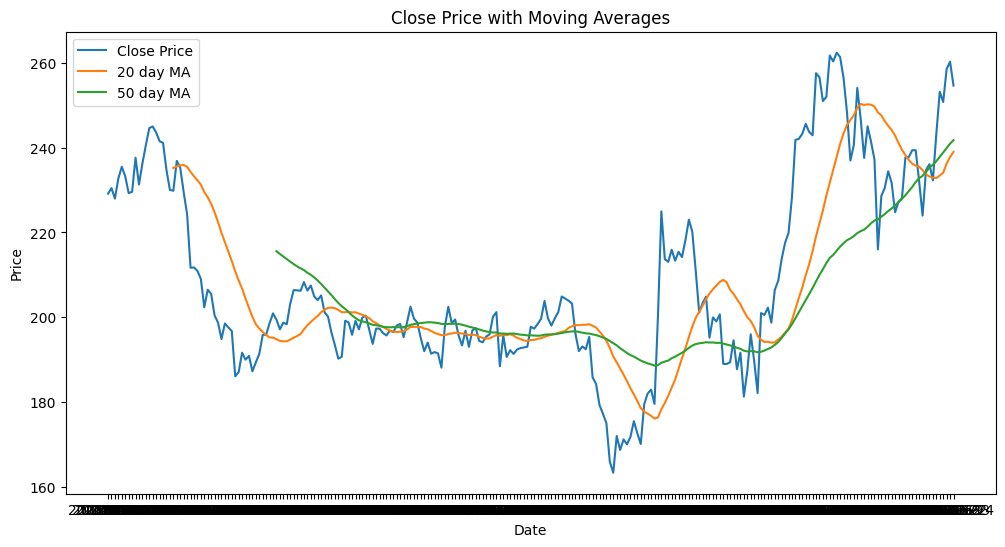

Price,Close,MA_20,MA_50
Date,,,
2026-06-11,223.949997,234.665999,233.3316
2026-06-12,234.679993,233.697498,234.2306
2026-06-15,236.070007,233.163499,235.3094
2026-06-16,232.259995,232.898998,235.9350
2026-06-17,243.190002,232.808498,236.7878
2026-06-18,253.149994,233.395998,237.8056
2026-06-19,250.740005,234.072999,238.8456
2026-06-22,258.500000,236.197999,239.8864
2026-06-23,260.239990,237.779998,240.9194


In [6]:
plt.figure(figsize=(12,6))
plt.plot(eng.index , eng["Close"],label="Close Price")
plt.plot(eng.index , eng["MA_20"], label="20 day MA")
plt.plot(eng.index , eng["MA_50"], label="50 day MA")
plt.title("Close Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()
eng[["Close","MA_20","MA_50"]].tail(10)


In [7]:
(eng["MA_20"] > eng["MA_50"]).tail(20)

Date
2026-05-27     True
2026-05-29     True
2026-06-01     True
2026-06-02     True
2026-06-03     True
2026-06-04     True
2026-06-05     True
2026-06-08     True
2026-06-09     True
2026-06-10     True
2026-06-11     True
2026-06-12    False
2026-06-15    False
2026-06-16    False
2026-06-17    False
2026-06-18    False
2026-06-19    False
2026-06-22    False
2026-06-23    False
2026-06-24    False
dtype: bool

In [8]:
#performance analysis :
# feature 2 -> cumulative return
eng.columns
# eng.drop(columns=["returns", "Returns"], inplace=True)
eng["Returns"] = eng["Close"].pct_change()
eng["Cumulative_Returns"] = ( 1 + eng["Returns"]).cumprod()
eng.columns

eng[["Returns","Cumulative_Returns"]].tail()


Price,Returns,Cumulative_Returns
Date,,
2026-06-18,0.040956,1.104876
2026-06-19,-0.009520,1.094358
2026-06-22,0.030948,1.128226
2026-06-23,0.006731,1.135821
2026-06-24,-0.021672,1.111205


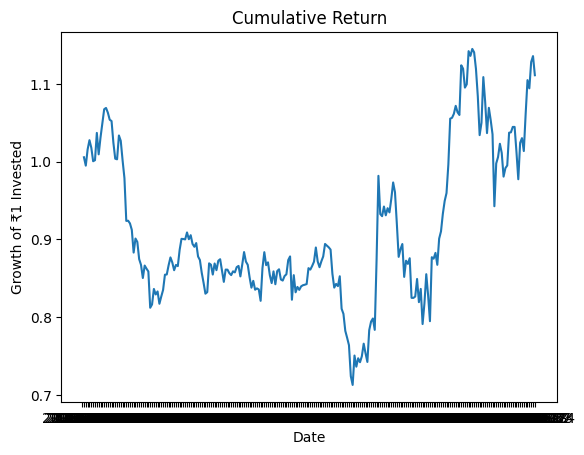

In [9]:
plt.Figure(figsize=(12,6))
plt.plot(eng.index , eng["Cumulative_Returns"])
plt.title("Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1 Invested")

plt.show()


In [10]:
#drawdown analysis :
eng["rolling_max"] = eng["Cumulative_Returns"].cummax()
eng[["Cumulative_Returns", "rolling_max"]].head(15)
eng["drawdown"] = (eng["Cumulative_Returns"]-eng["rolling_max"])/eng["rolling_max"]
eng.columns
eng[["Cumulative_Returns", "rolling_max", "drawdown"]].tail(10)
max_drawdown = eng["drawdown"].min()
print(f"msx drawdoan = :{max_drawdown:2%}") 

msx drawdoan = :-33.313907%


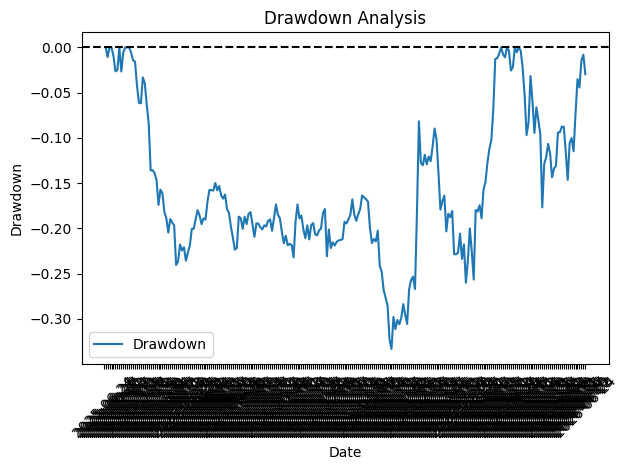

In [11]:
#drawdown chart
plt.Figure(figsize=(12,6))
plt.plot(eng.index , eng["drawdown"],label="Drawdown")
plt.axhline(y=0,
            color="black",
            linestyle="--")
plt.title("Drawdown Analysis")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()

plt.show()

In [12]:
eng["rolling_volatility"] = eng["Returns"].rolling(window=20).std()
eng[["Returns", "rolling_volatility"]].tail(25)

Price,Returns,rolling_volatility
Date,,
2026-05-20,-0.014694,0.029151
2026-05-21,-0.017398,0.029309
2026-05-22,-0.089376,0.035317
2026-05-25,0.058333,0.038091
2026-05-26,0.008311,0.035263
2026-05-27,0.016920,0.035601
2026-05-29,-0.011519,0.035403
2026-06-01,-0.030082,0.035847
2026-06-02,0.011124,0.034580


In [13]:
#rsi =  relative strength index 
eng["change"] = eng["Close"].diff()
eng[["Close","change"]].head()
eng["gain"] = eng["change"].clip(lower=0)
eng["loss"] = -eng["change"].clip(upper=0)
eng[["change","gain","loss"]].head(10)
eng["avg_gain"] = eng['gain'].rolling(window=14).mean()
eng["avg_loss"] = eng['loss'].rolling(window=14).mean()

eng[["gain", "loss", "avg_gain", "avg_loss"]].head(20)
# eng.columns
eng["RS"] = eng["avg_gain"] / eng["avg_loss"]
eng["RSI"] = 100 - (100 / (1 + eng["RS"]))
eng[["avg_gain", "avg_loss", "RS", "RSI"]].tail(15)

Price,avg_gain,avg_loss,RS,RSI
Date,,,,
2026-06-04,2.770714,3.940714,0.703099,41.283522
2026-06-05,2.778571,3.419285,0.812617,44.831161
2026-06-08,2.892142,2.762143,1.047065,51.149566
2026-06-09,2.360000,2.762143,0.854409,46.074463
2026-06-10,2.360000,3.027856,0.779429,43.802205
2026-06-11,2.360000,3.306428,0.713761,41.648807
2026-06-12,3.126428,1.792143,1.744520,63.563750
2026-06-15,2.325714,1.792143,1.297728,56.478753
2026-06-16,2.190000,2.064286,1.060899,51.477497


In [14]:
eng.to_csv("../data/processed/enginersin_features.csv")